# Part1:Omar

# Import library and Functions.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

#     تسلسل الخطوات من معالجه ك تسلسل المحاضرات 

# Read the DataSet file

In [6]:
df=pd.read_csv('adult.csv')
df.columns

Index(['39', ' State-gov', ' 77516', ' Bachelors', ' 13', ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', ' 2174', ' 0',
       ' 40', ' United-States', ' <=50K'],
      dtype='object')

# Change columns names

In [8]:
df.rename(columns={'39': 'Age'}, inplace=True)
df.rename(columns={' State-gov': 'State-gov'}, inplace=True)
df.rename(columns={' 77516': 'Salary'}, inplace=True)
df.rename(columns={' Bachelors': 'Bachelors'}, inplace=True)
df.rename(columns={' 13': 'Education_Level'}, inplace=True)
df.rename(columns={' Never-married': 'Never-married'}, inplace=True)
df.rename(columns={' Adm-clerical': 'Occupation'}, inplace=True)
df.rename(columns={' Not-in-family': 'Relationship'}, inplace=True)
df.rename(columns={' White': 'Race'}, inplace=True)
df.rename(columns={' Male': 'Gender'}, inplace=True)
df.rename(columns={' 2174': 'Capital_Gain'}, inplace=True)
df.rename(columns={' 0': 'Capital Loss'}, inplace=True)
df.rename(columns={' 40': 'Hours_per_Week'}, inplace=True)
df.rename(columns={' United-States': 'Native Country'}, inplace=True)
df.rename(columns={' <=50K': 'Income'}, inplace=True)
df.columns

Index(['Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country',
       'Income'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              32560 non-null  int64 
 1   State-gov        32560 non-null  object
 2   Salary           32560 non-null  int64 
 3   Bachelors        32560 non-null  object
 4   Education_Level  32560 non-null  int64 
 5   Never-married    32560 non-null  object
 6   Occupation       32560 non-null  object
 7   Relationship     32560 non-null  object
 8   Race             32560 non-null  object
 9   Gender           32560 non-null  object
 10  Capital_Gain     32560 non-null  int64 
 11  Capital Loss     32560 non-null  int64 
 12  Hours_per_Week   32560 non-null  int64 
 13  Native Country   32560 non-null  object
 14  Income           32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
df.describe()

,Age,Salary,Education_Level,Capital_Gain,Capital Loss,Hours_per_Week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [11]:
df.head()

,Age,State-gov,Salary,Bachelors,Education_Level,Never-married,Occupation,Relationship,Race,Gender,Capital_Gain,Capital Loss,Hours_per_Week,Native Country,Income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


# Displaying objects in Dataset

In [13]:
df.describe(include=[object])

,State-gov,Bachelors,Never-married,Occupation,Relationship,Race,Gender,Native Country,Income
count,32560,32560,32560,32560,32560,32560,32560,32560,32560
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27815,21789,29169,24719


In [14]:
print(df["Bachelors"].value_counts())
print(df["State-gov"].value_counts())
print(df["Never-married"].value_counts())
print(df["Occupation"].value_counts())
print(df["Relationship"].value_counts())
print(df["Race"].value_counts())
print(df["Gender"].value_counts())
print(df["Native Country"].value_counts())
print(df["Income"].value_counts())


Bachelors
HS-grad         10501
Some-college     7291
Bachelors        5354
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
State-gov
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1297
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
Never-married
Married-civ-spouse       14976
Never-married            10682
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
Occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4

# Visualizing object in dataset

# 1-lineplot
<p>سوف تعرض كيف تتغير القيم عبر متغير مستمر الهدف وهو الدخل</p>

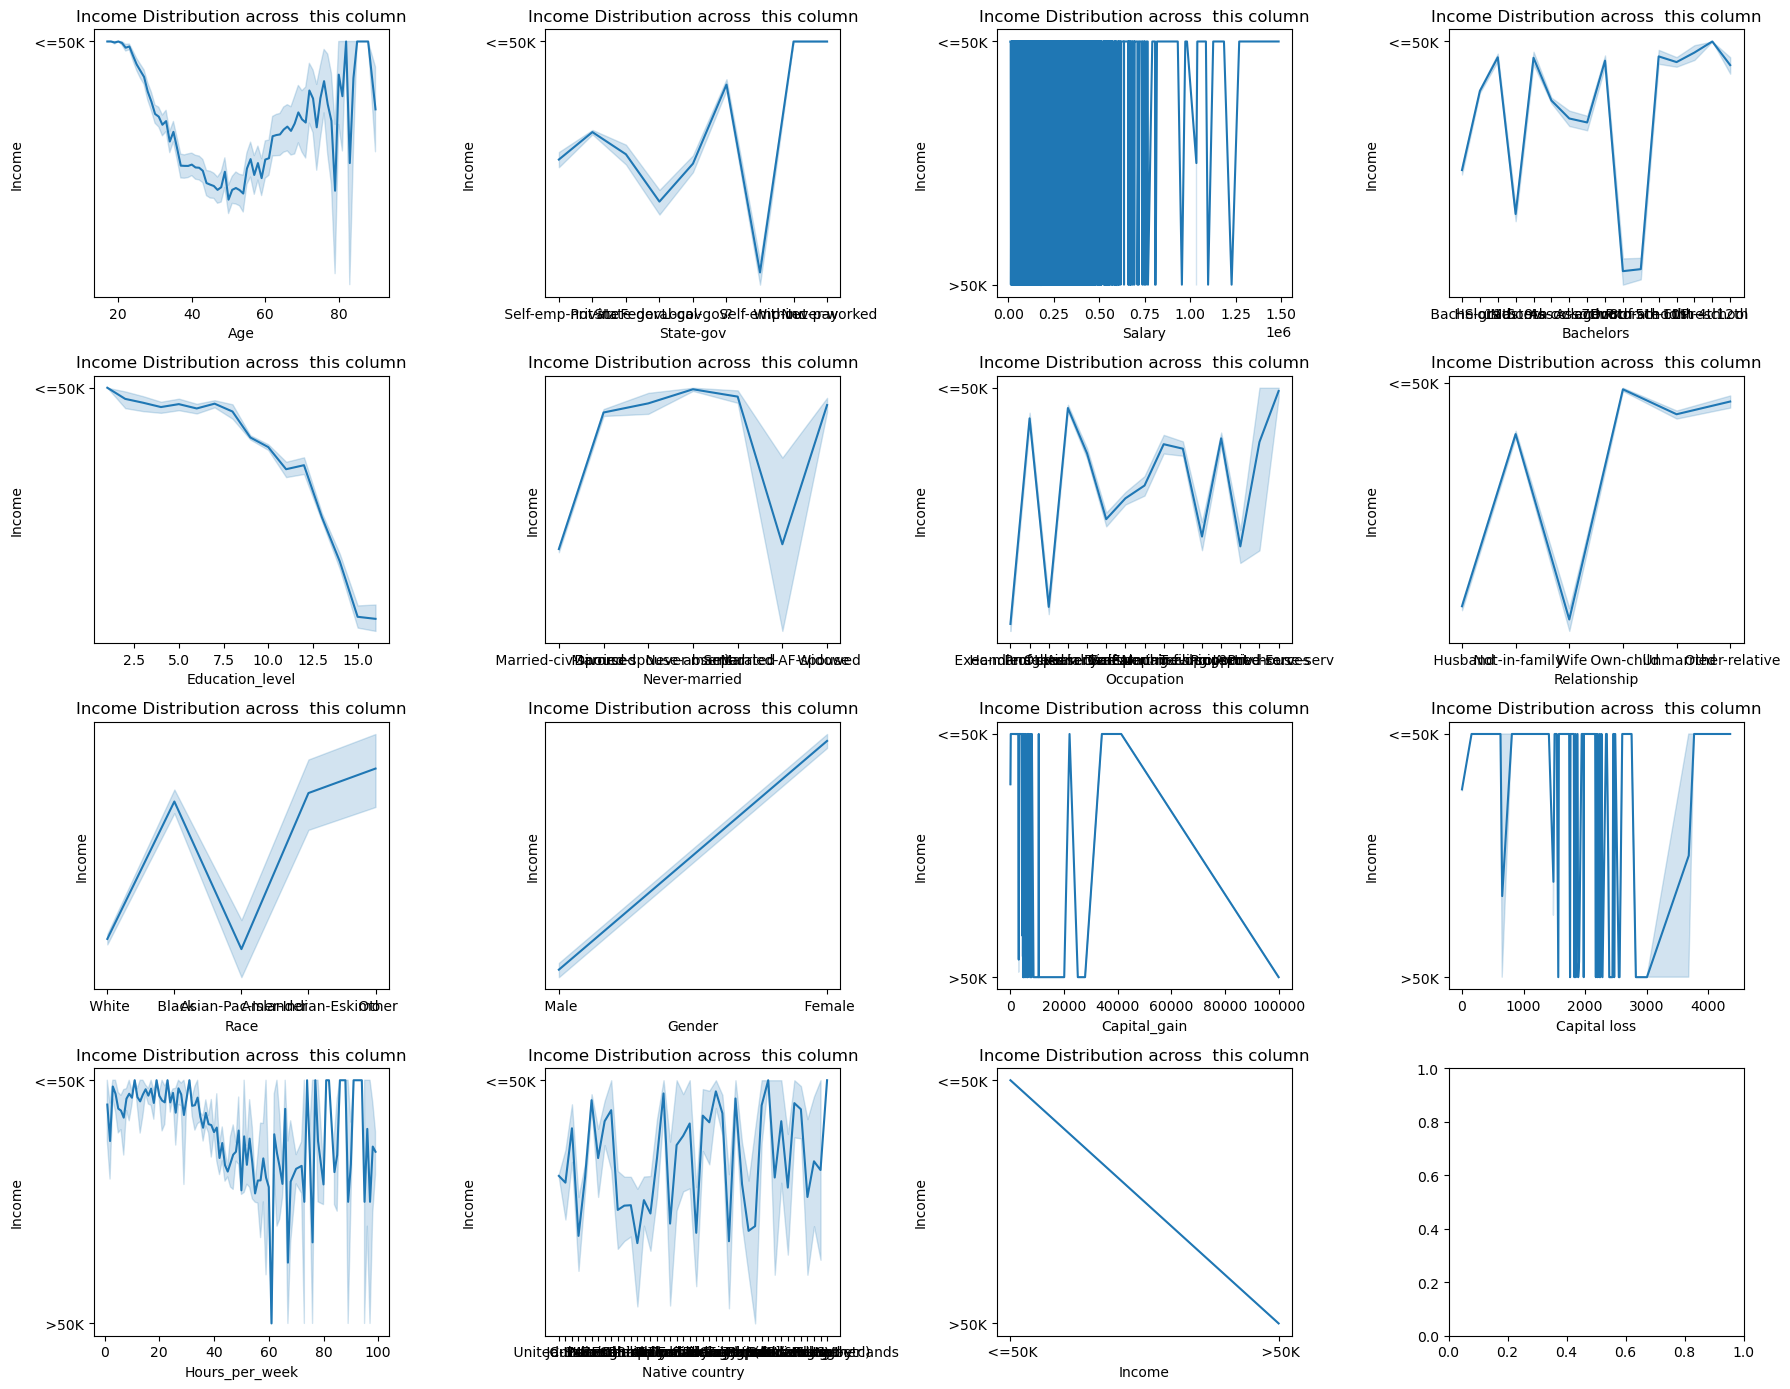

In [17]:
columns = ['Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country',
       'Income']
titles = ['Income Distribution across  this column']

fig, axs = plt.subplots(4, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.lineplot(data=df, x=col, y='Income', ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Income')

fig.tight_layout()
plt.show()


# 2-scatterplot
<p>سوف نعرض البيانات بشكل مرئي لكي نفهم توزيع البيانات مع الدخل</p>

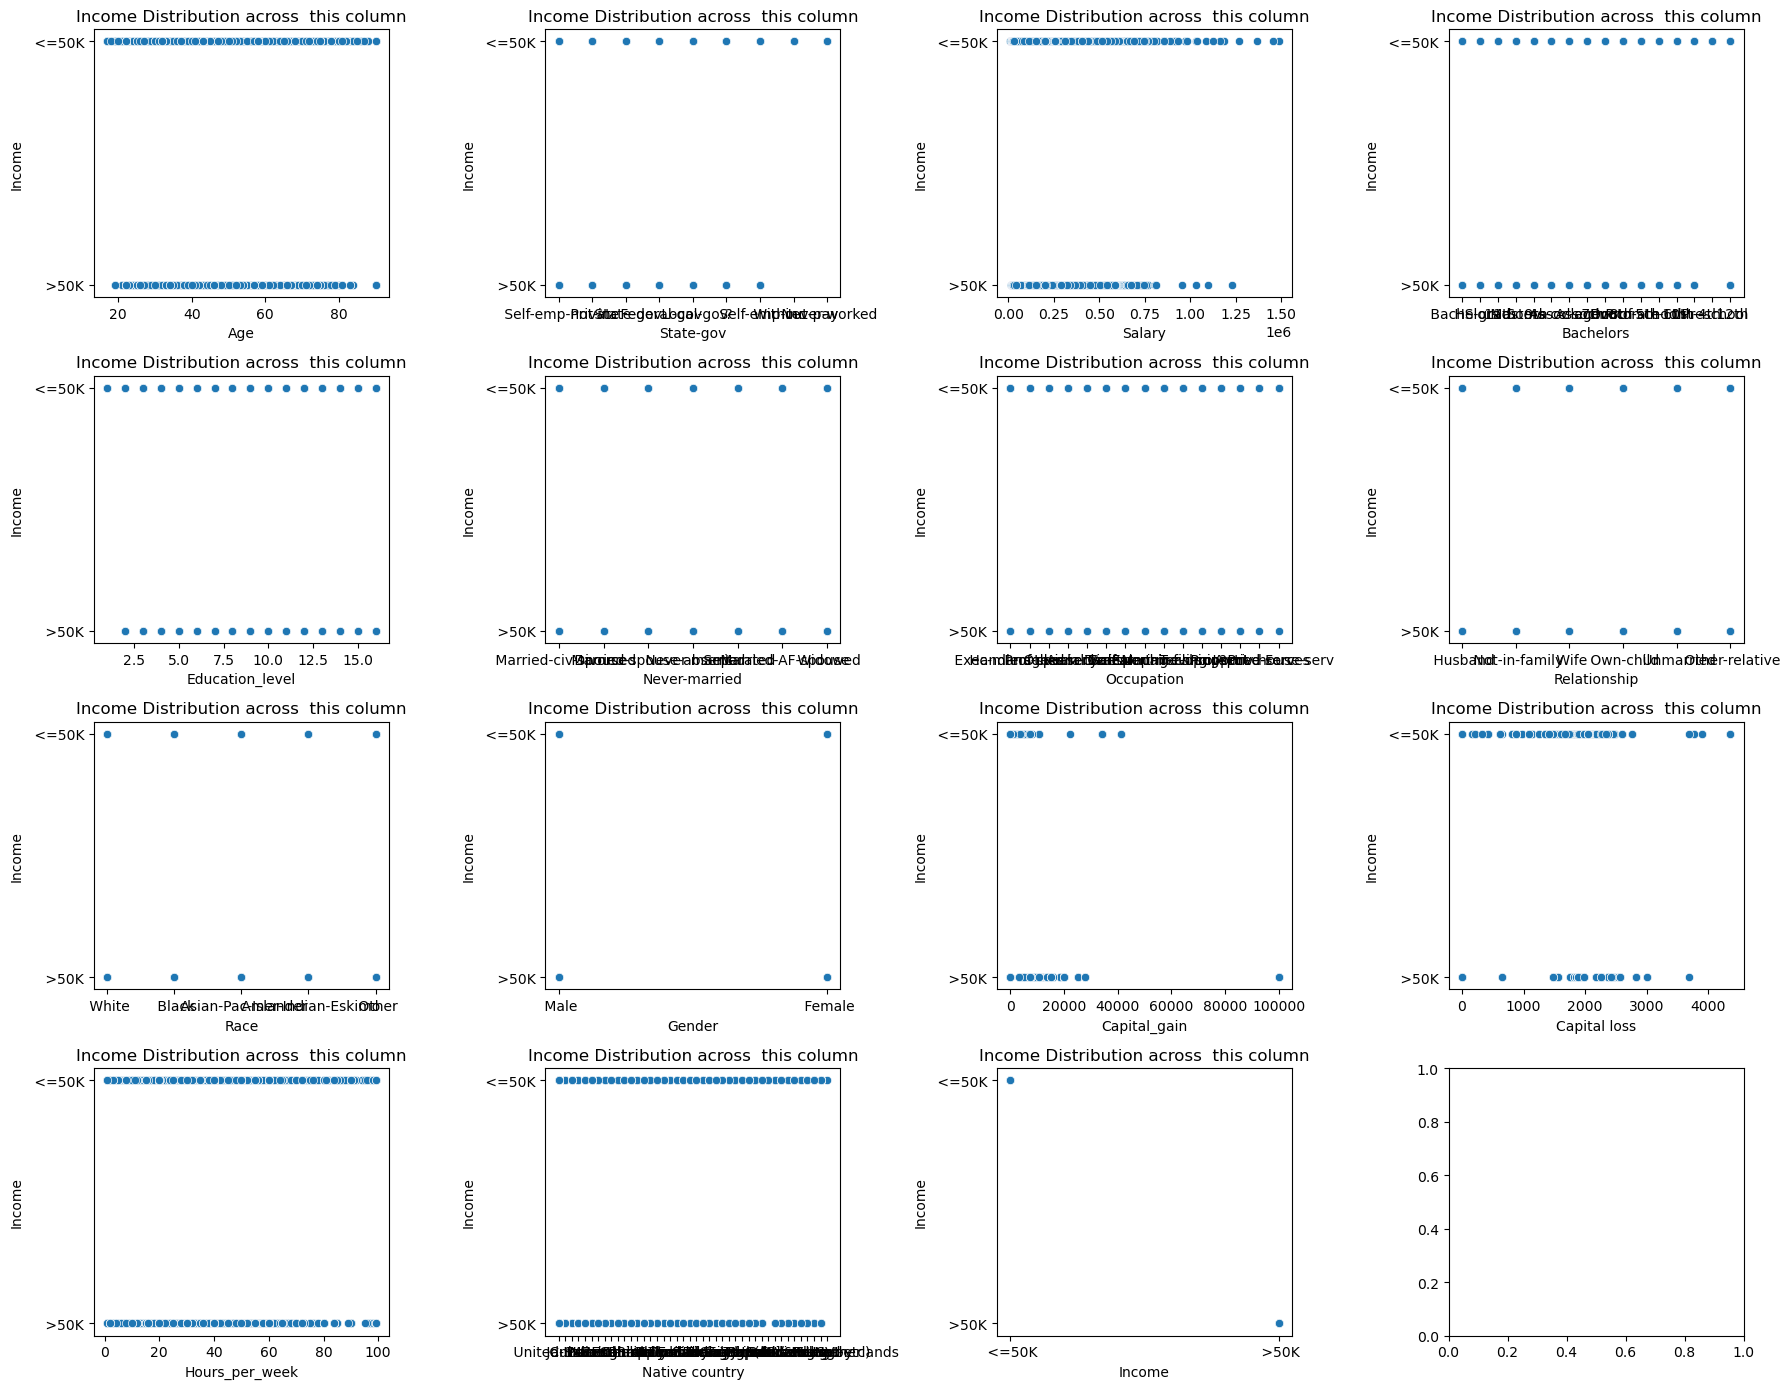

In [19]:
columns = ['Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country',
       'Income']
titles = ['Income Distribution across  this column']

fig, axs = plt.subplots(4, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.scatterplot(data=df, x=col, y='Income', ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Income')

fig.tight_layout()
plt.show()


# 3-barplot
<p>سوف نستخدمه لعرض عدد العينات لكل فئه من الفئه التصنيفيه يهمنا في العامود الغير مستمر.قمنا بوضعه لجميع الاعمده</p>

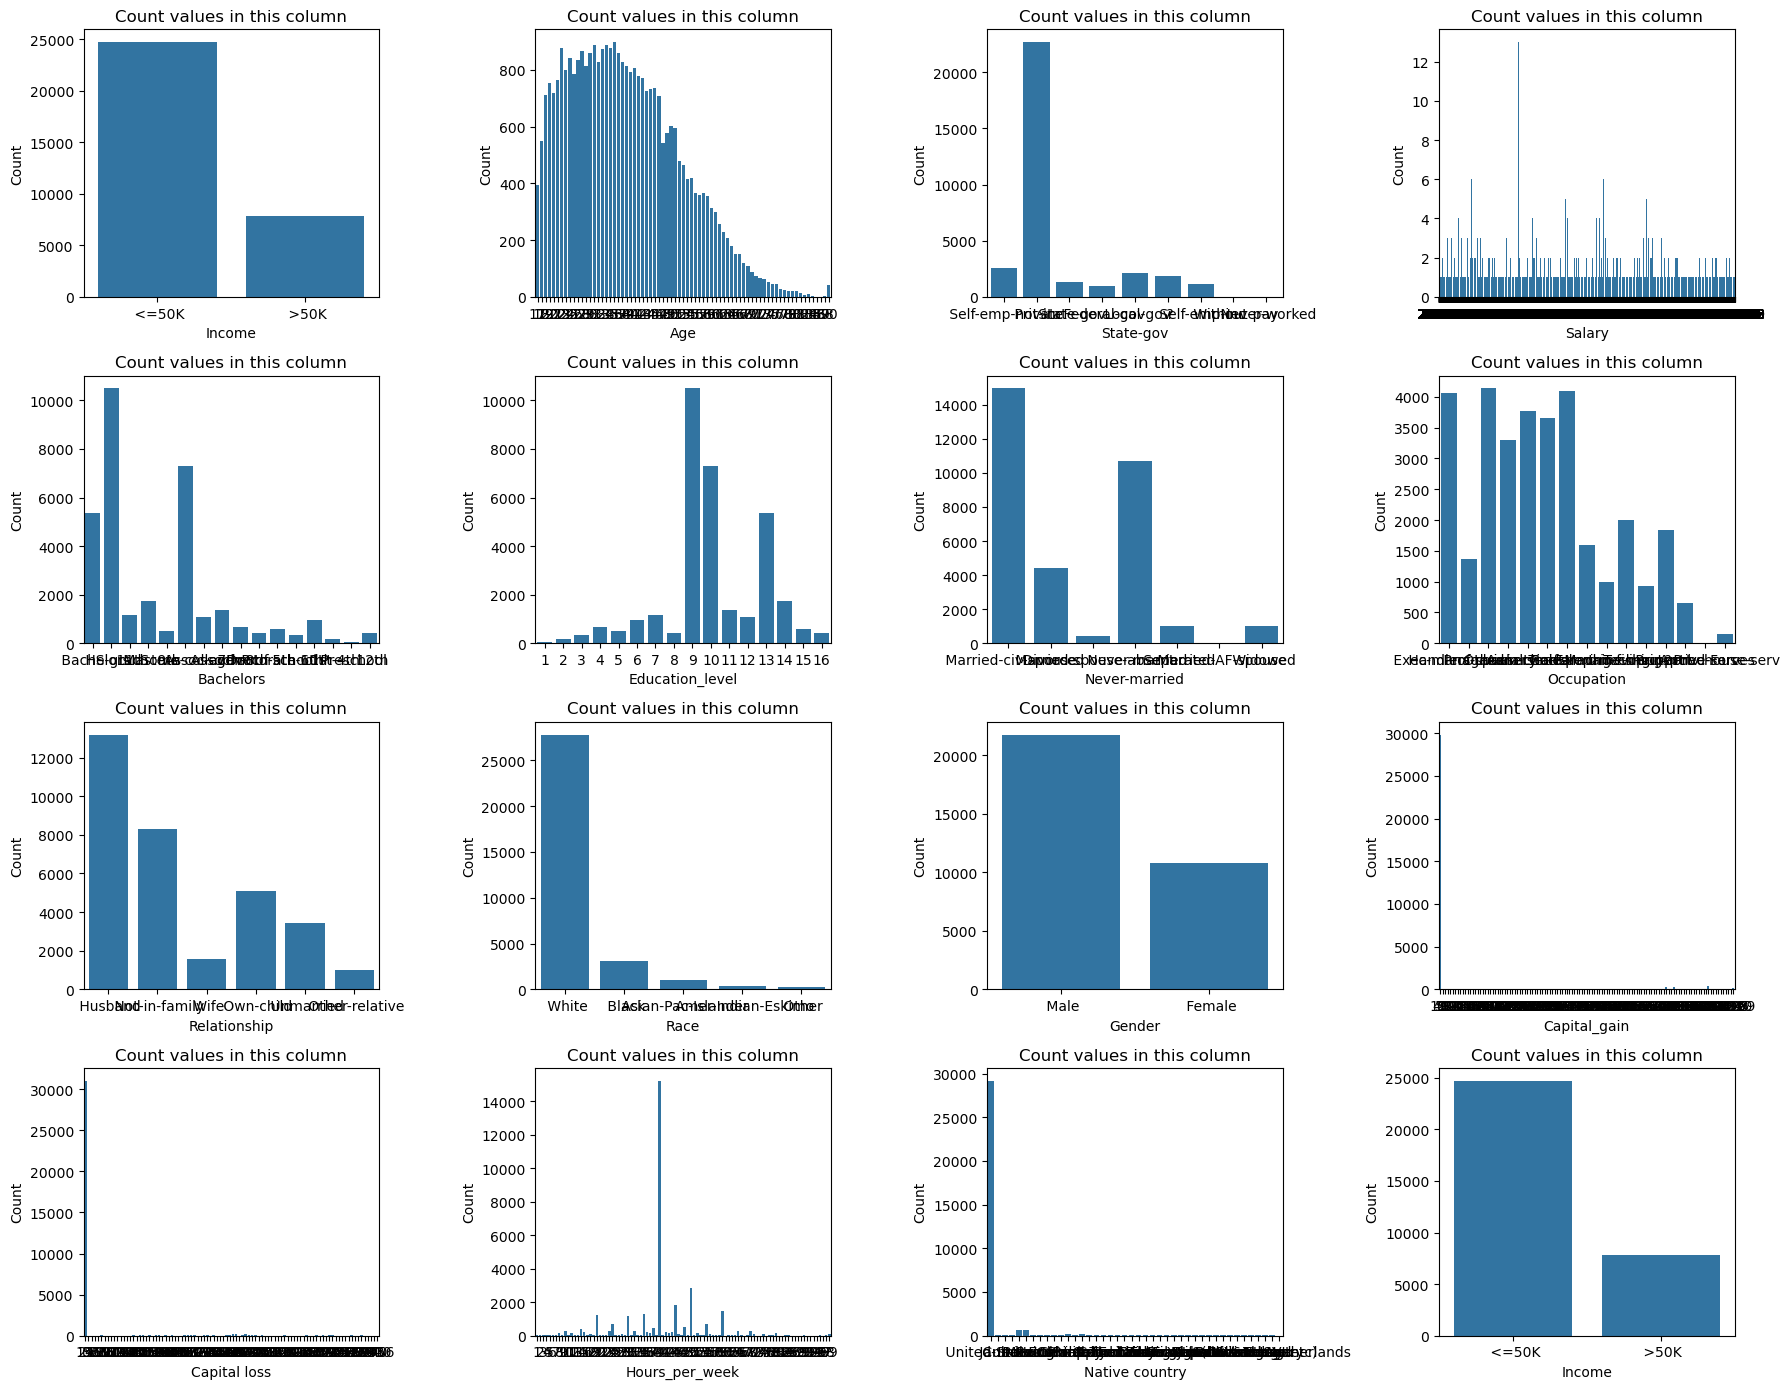

In [21]:
columns = ['Income', 'Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country',
       'Income']
titles = ['Count values in this column']

fig, axs = plt.subplots(4, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.countplot(data=df, x=col, ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Count')

fig.tight_layout()
plt.show()


# 4-histogram
 <p>يستخدم لمعرفه توزيع القيم في كل عامود ويمكن استخدامه في القيم المستمره ويمكن استنتاج القيم الشاذه منه</p>

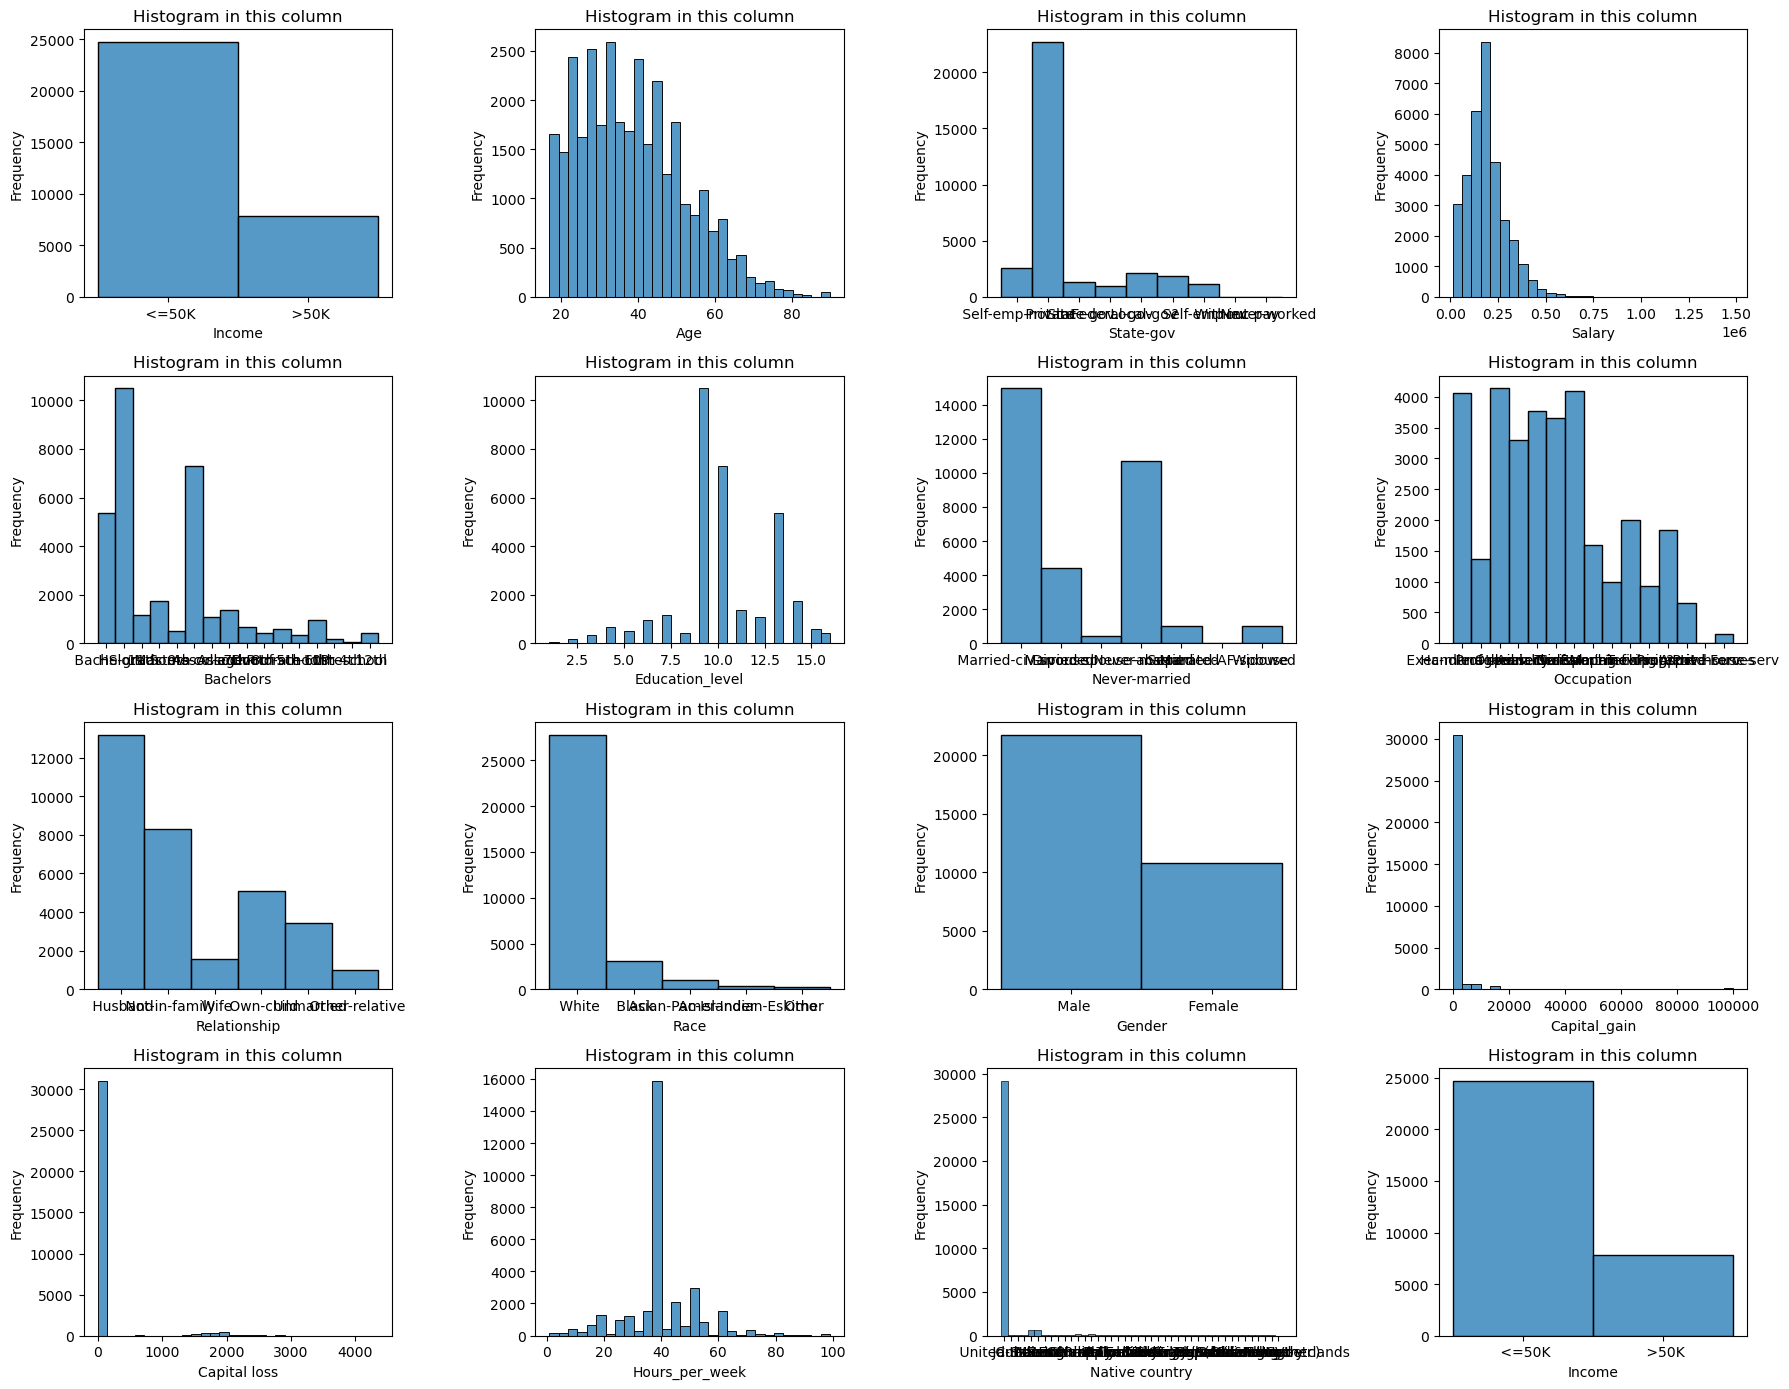

In [23]:
columns = ['Income', 'Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country',
       'Income']
titles = ['Histogram in this column']

fig, axs = plt.subplots(4, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, ax=axs[i//4, i%4], bins=30)
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Frequency')

fig.tight_layout()
plt.show()


# 5-boxplot
<p>يستخدم لتحديد القيم الشاذه</p>

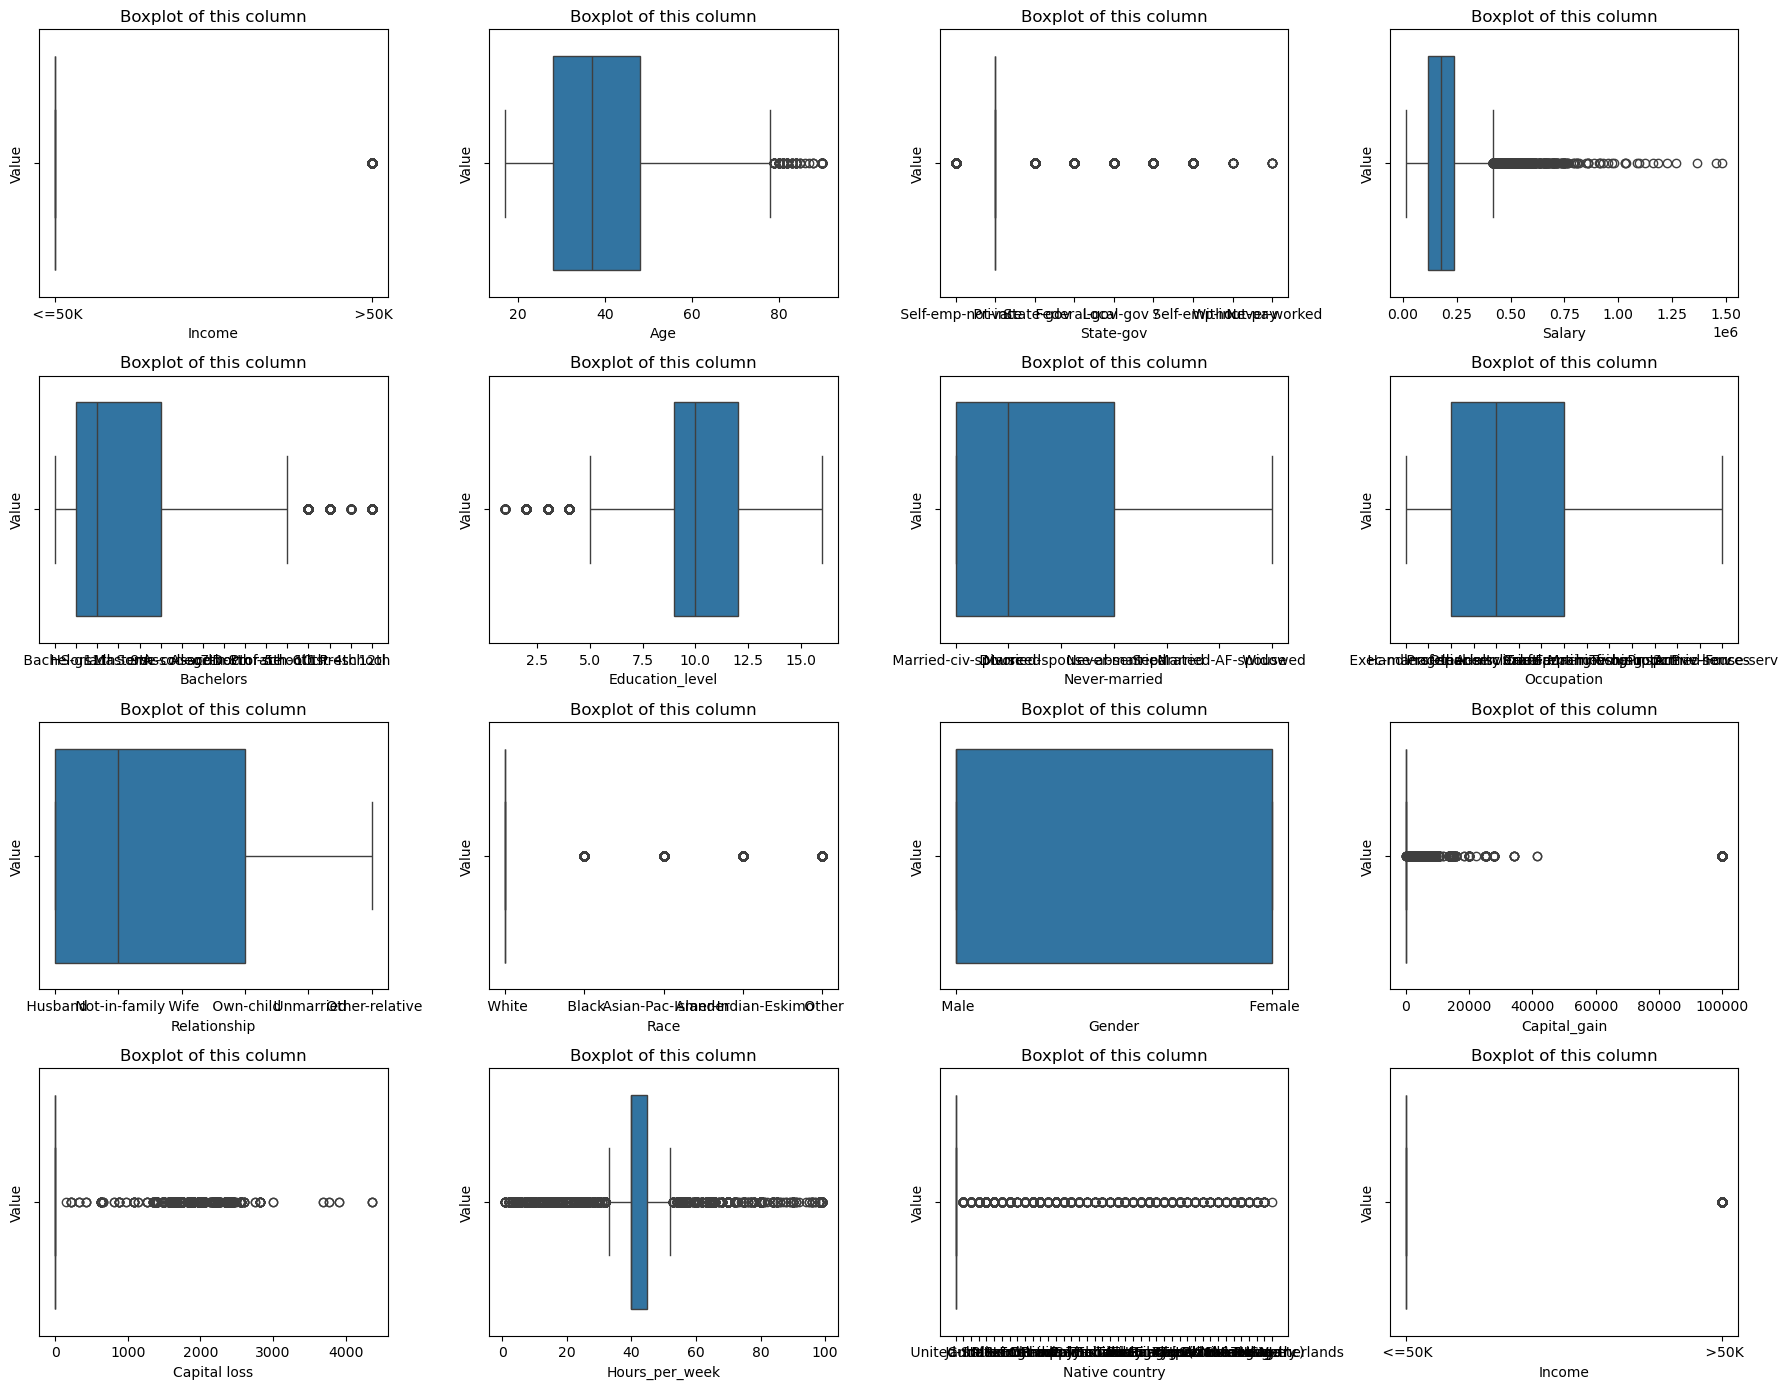

In [25]:
columns = ['Income', 'Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country',
       'Income']
titles = ['Boxplot of this column']

fig, axs = plt.subplots(4, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.boxplot(data=df, x=col, ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Value')

fig.tight_layout()
plt.show()


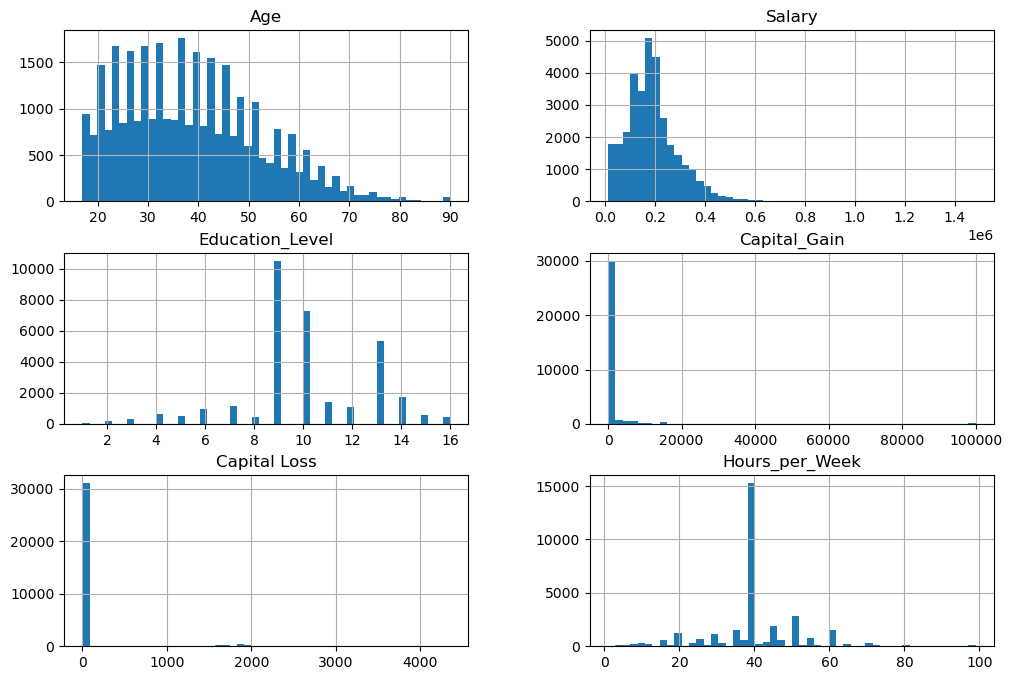

In [26]:
df.hist(bins=50, figsize=(12,8))
plt.show()

# Handle missing values

<BarContainer object of 15 artists>

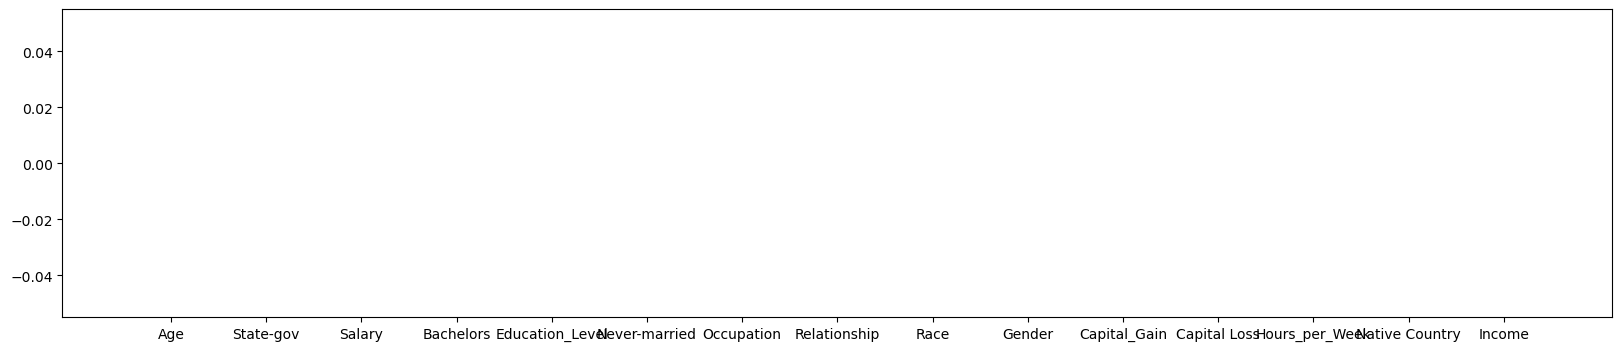

In [28]:
plt.figure(figsize=(20, 4))
plt.bar(df.columns, df.isnull().sum())

In [29]:
#We note that there are no missing values.
#If there are any, the numbers will be processed using the arithmetic mean,
#df1 = df2.fillna(df.columns.mean()) 
#and the texts using the most repeated value.

# Outliers processing
<p>The IsolationForest algorithm gave better results than determining (Lower Bound and Upper Bound).</p>

In [31]:
# calculate summary statistics 
columns_to_plot = ['Age', 'Salary', 'Education_Level', 'Capital_Gain', 'Hours_per_Week', 'Capital Loss']
d=df.select_dtypes(include=[np.number])
df1 = pd.DataFrame()
for column in columns_to_plot:
    mean = d[column].mean() 
    std = d[column].std() 
    
    # Calculate the lower and upper bounds 
    lower_bound = mean - std * 2
    upper_bound = mean + std * 2
    
    print('Lower Bound for', column, ':', lower_bound) 
    print('Upper Bound for', column, ':', upper_bound) 
    print("-------------")
    # Drop the outliers
    df1[column] = d[(d[column] >= lower_bound) & (d[column] <= upper_bound)][column]
#  nanعند حصر المجال بهذه الطريقه وحذف القيم خارج هذا المجال سيؤدي الي وجود قيم 
#  IsolationForest على عكس 

Lower Bound for Age : 11.300350251705812
Upper Bound for Age : 65.862917561562
-------------
Lower Bound for Salary : -21317.715475289733
Upper Bound for Salary : 400881.3442222185
-------------
Lower Bound for Education_Level : 4.93517174437913
Upper Bound for Education_Level : 15.226007616800231
-------------
Lower Bound for Capital_Gain : -13693.190825109557
Upper Bound for Capital_Gain : 15848.421169089901
-------------
Lower Bound for Hours_per_Week : 15.742233170508197
Upper Bound for Hours_per_Week : 65.13270540443037
-------------
Lower Bound for Capital Loss : -718.6257215028147
Upper Bound for Capital Loss : 893.2387436158367
-------------


<BarContainer object of 6 artists>

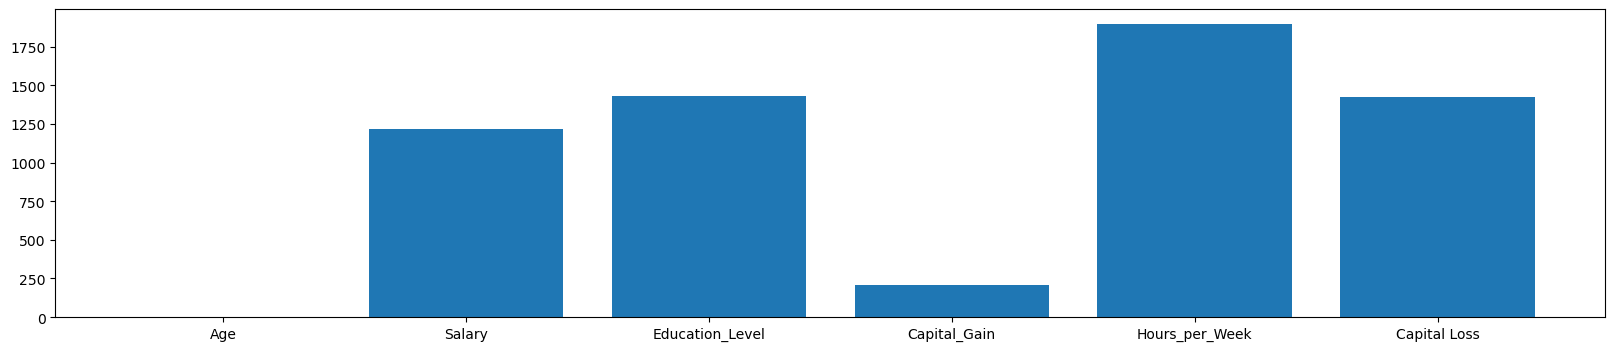

In [32]:
plt.figure(figsize=(20, 4))
plt.bar(df1.columns, df1.isnull().sum())

In [33]:
#Handle missing values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
imputer.fit(df1)
df1=imputer.transform(df1)
print('missing value:',df1.isnull().any(axis=1).sum())

missing value: 0


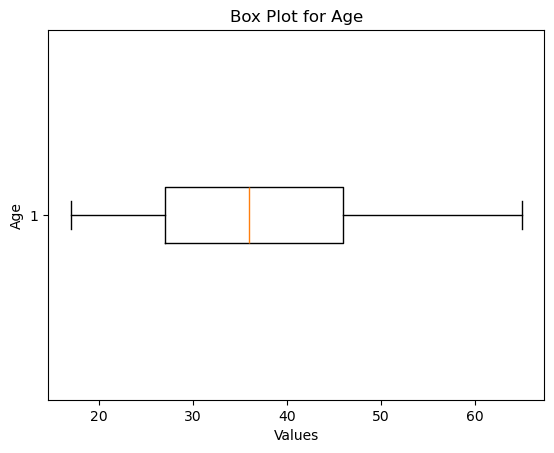

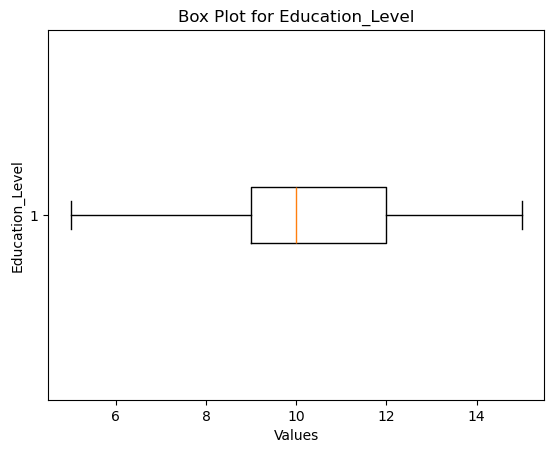

In [34]:
columns_to_plot = ['Age', 'Education_Level']
for column in columns_to_plot:
    plt.figure()
    plt.boxplot(df1[column], vert=False)
    plt.ylabel(column)
    plt.xlabel('Values')
    plt.title(f'Box Plot for {column}')
    plt.show()

In [35]:
df1.columns

Index(['Age', 'Salary', 'Education_Level', 'Capital_Gain', 'Hours_per_Week',
       'Capital Loss'],
      dtype='object')

# Data Encoding 

In [37]:
#using label encoder for columns: Incom --->just 2 values
from sklearn.preprocessing import LabelEncoder  
encoder = LabelEncoder()
d2 = pd.DataFrame()
#for col in columns_to_encode:
d2['Incom'+'_enc'] = encoder.fit_transform(df['Income'])
df.drop('Income', axis=1, inplace=True)


# Applay Heatmap

In [39]:
#Merge number columns with text columns after encoding
d3=pd.merge(d2, df1, left_index=True, right_index=True)

In [40]:
d3.columns

Index(['Incom_enc', 'Age', 'Salary', 'Education_Level', 'Capital_Gain',
       'Hours_per_Week', 'Capital Loss'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1400x1000 with 0 Axes>

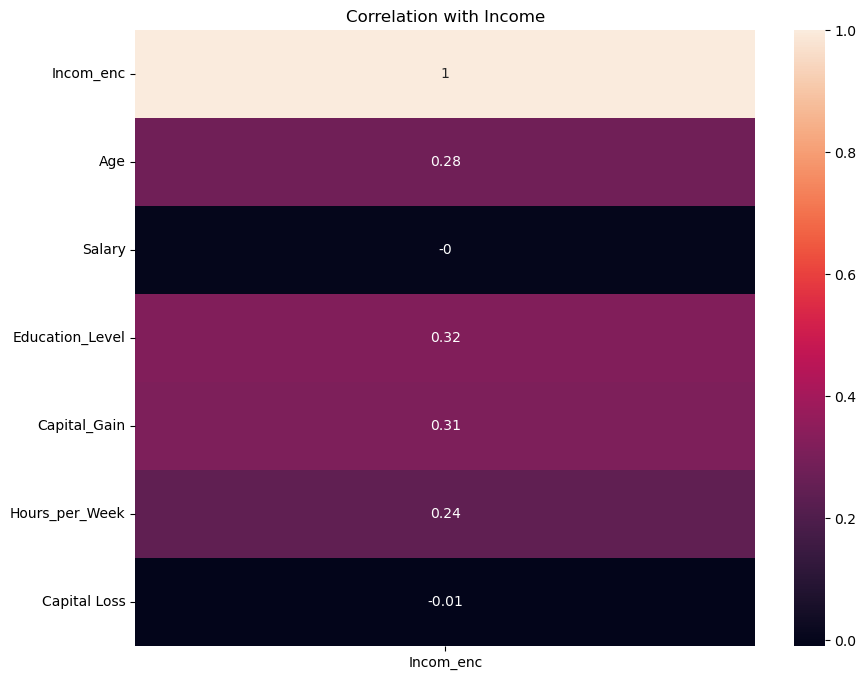

In [41]:
plt.figure(figsize=(14, 10))
correlation_matrix = d3.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['Incom_enc']].round(2), annot=True, fmt='g')
plt.title('Correlation with Income')
plt.show

In [42]:
#We notice from the histogram that the capital loss column has all zero values,
# Salary was removed as there is no relationship between it and income
#so we will delete it because it is not important.
df1.drop(columns=['Capital Loss','Salary'], inplace=True) 
df.columns

Index(['Age', 'State-gov', 'Salary', 'Bachelors', 'Education_Level',
       'Never-married', 'Occupation', 'Relationship', 'Race', 'Gender',
       'Capital_Gain', 'Capital Loss', 'Hours_per_Week', 'Native Country'],
      dtype='object')

In [43]:
#using OneHot Encoder for columns: State-gov, Bachelors, Never-married,
#Occupation, Relationship, Race, Gender, Native Country--->more than 5 values
from sklearn.preprocessing import OneHotEncoder
d0=df.select_dtypes(include=[object])

columns_to_encode = [' State-gov', ' Bachelors', ' Never-married',
'Occupation', 'Relationship', 'Race', 'Gender', 'Native Country']
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder = onehot_encoder.fit(d0)

d3 = onehot_encoder.transform(d0)


In [44]:
#Merge text columns after encoding
df2=pd.merge(d2, d3, left_index=True, right_index=True)

In [45]:
df2.columns

Index(['Incom_enc', 'State-gov_ ?', 'State-gov_ Federal-gov',
       'State-gov_ Local-gov', 'State-gov_ Never-worked', 'State-gov_ Private',
       'State-gov_ Self-emp-inc', 'State-gov_ Self-emp-not-inc',
       'State-gov_ State-gov', 'State-gov_ Without-pay',
       ...
       'Native Country_ Portugal', 'Native Country_ Puerto-Rico',
       'Native Country_ Scotland', 'Native Country_ South',
       'Native Country_ Taiwan', 'Native Country_ Thailand',
       'Native Country_ Trinadad&Tobago', 'Native Country_ United-States',
       'Native Country_ Vietnam', 'Native Country_ Yugoslavia'],
      dtype='object', length=103)

In [46]:
#Merge number columns with text columns after encoding
df3=pd.merge(df2, df1, left_index=True, right_index=True)

In [47]:
df3.columns

Index(['Incom_enc', 'State-gov_ ?', 'State-gov_ Federal-gov',
       'State-gov_ Local-gov', 'State-gov_ Never-worked', 'State-gov_ Private',
       'State-gov_ Self-emp-inc', 'State-gov_ Self-emp-not-inc',
       'State-gov_ State-gov', 'State-gov_ Without-pay',
       ...
       'Native Country_ Taiwan', 'Native Country_ Thailand',
       'Native Country_ Trinadad&Tobago', 'Native Country_ United-States',
       'Native Country_ Vietnam', 'Native Country_ Yugoslavia', 'Age',
       'Education_Level', 'Capital_Gain', 'Hours_per_Week'],
      dtype='object', length=107)

In [141]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31402 entries, 0 to 32559
Columns: 107 entries, Incom_enc to Hours_per_Week
dtypes: float64(106), int32(1)
memory usage: 25.8 MB


In [48]:
df3.describe()

,Incom_enc,State-gov_ ?,State-gov_ Federal-gov,State-gov_ Local-gov,State-gov_ Never-worked,State-gov_ Private,State-gov_ Self-emp-inc,State-gov_ Self-emp-not-inc,State-gov_ State-gov,State-gov_ Without-pay,...,Native Country_ Taiwan,Native Country_ Thailand,Native Country_ Trinadad&Tobago,Native Country_ United-States,Native Country_ Vietnam,Native Country_ Yugoslavia,Age,Education_Level,Capital_Gain,Hours_per_Week
count,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,...,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000,31402.000000
mean,0.242278,0.048723,0.029934,0.064550,0.000223,0.707917,0.033023,0.074963,0.040316,0.000350,...,0.001624,0.000573,0.000605,0.894975,0.002038,0.000478,37.356761,10.258009,511.527673,40.917139
std,0.428468,0.215292,0.170409,0.245734,0.014929,0.454728,0.178700,0.263336,0.196702,0.018713,...,0.040268,0.023935,0.024591,0.306591,0.045100,0.021851,12.227679,2.100373,2175.629678,8.602978
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.000000,0.000000,16.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,27.000000,9.000000,0.000000,40.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,36.000000,10.000000,0.000000,40.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,46.000000,12.000000,0.000000,45.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,65.000000,15.000000,15024.000000,65.000000


In [49]:
print(df3["Incom_enc"].value_counts())

Incom_enc
0    23794
1     7608
Name: count, dtype: int64


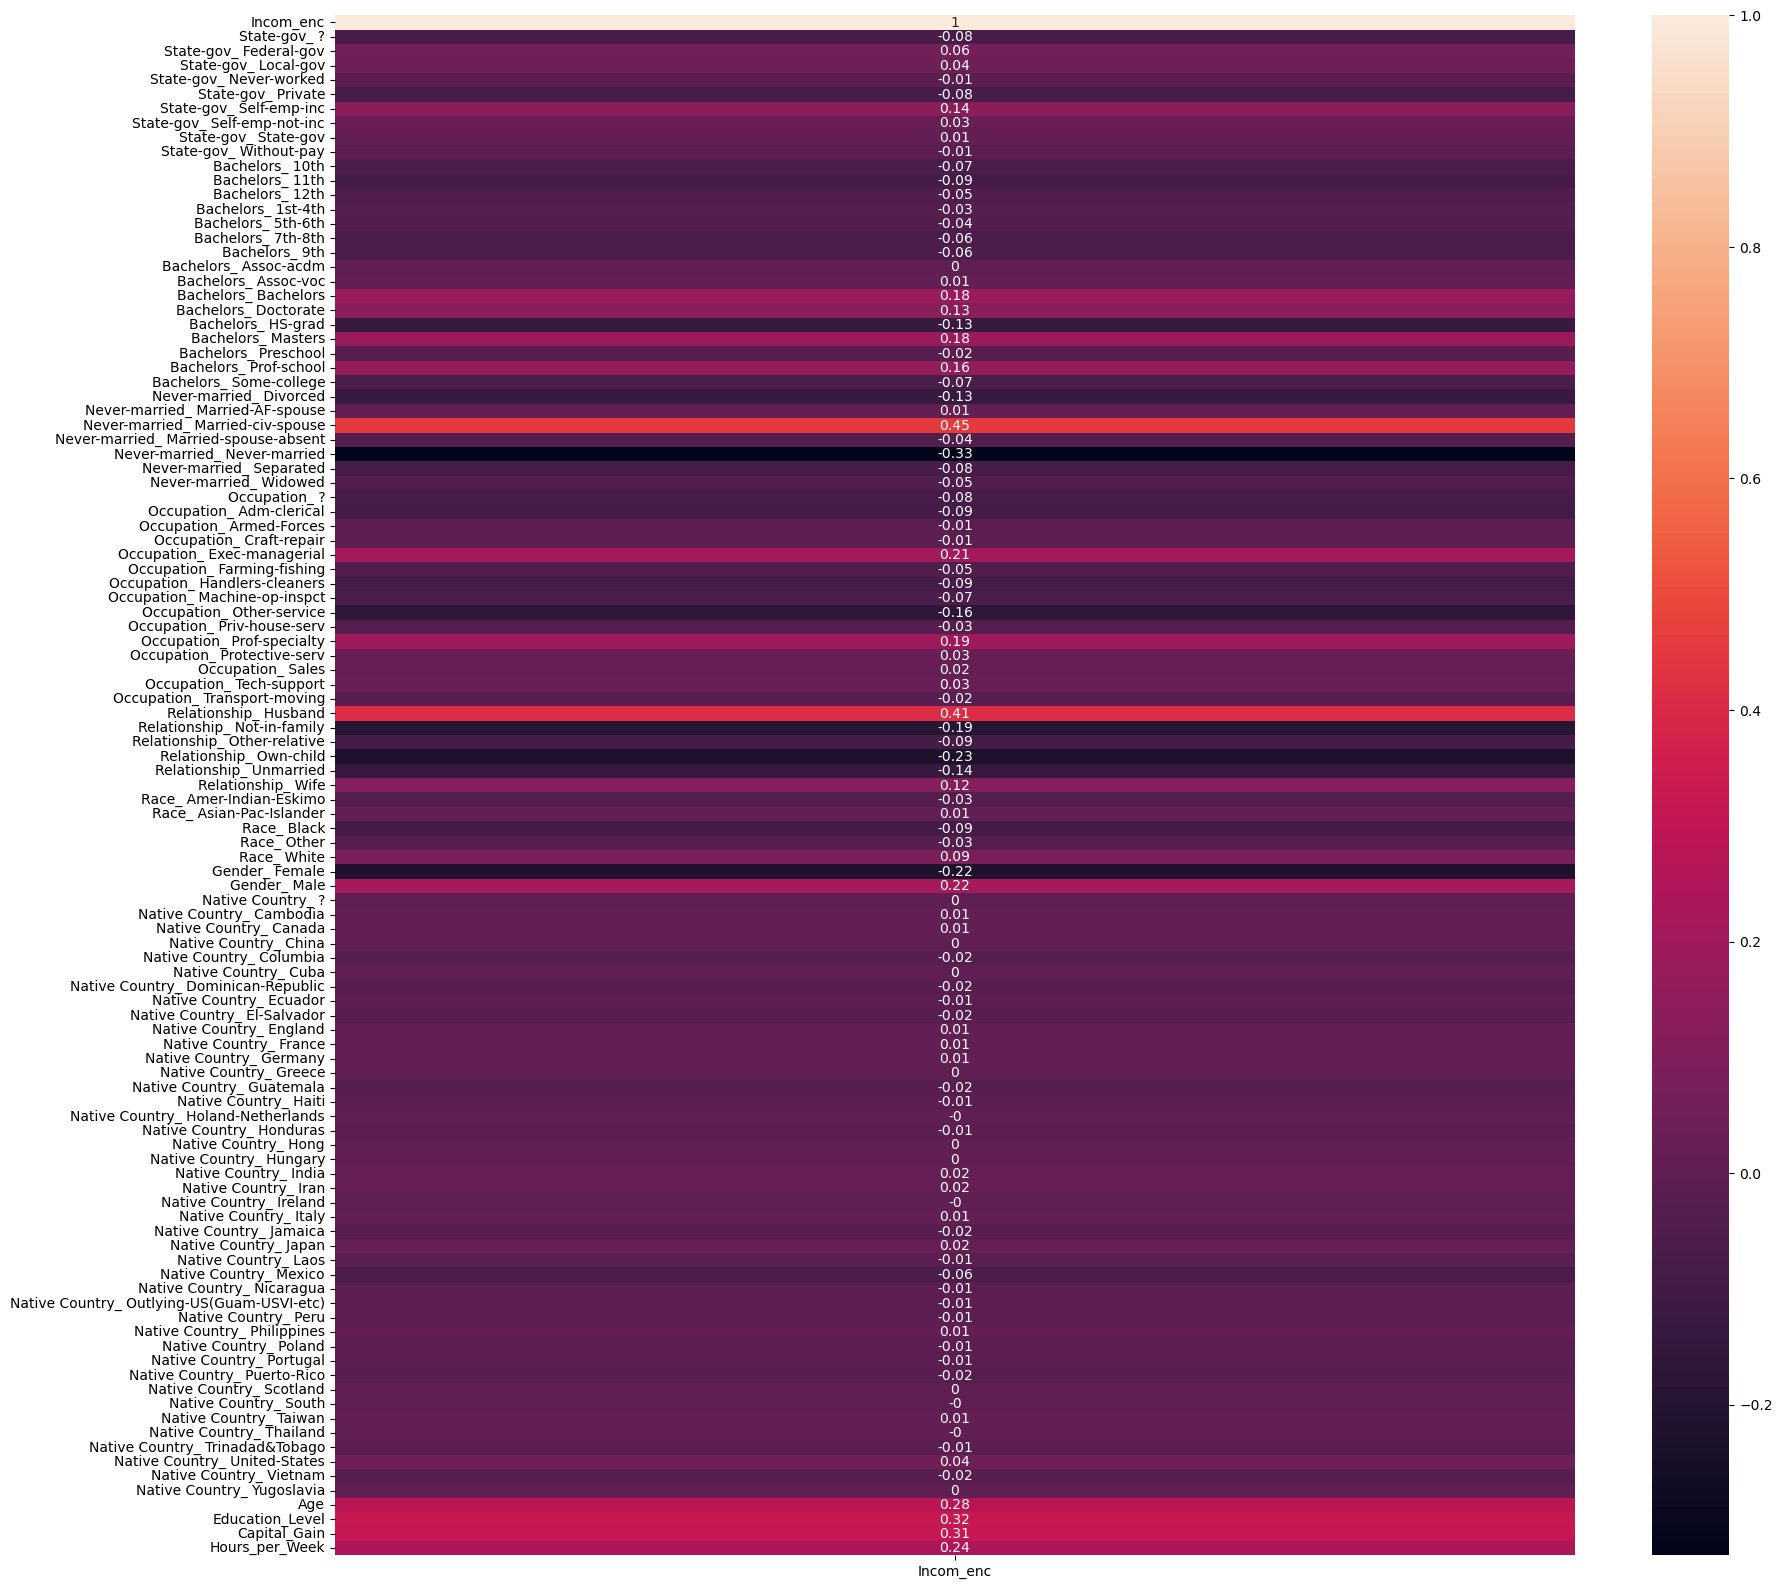

In [50]:
plt.figure(figsize=(20, 20))
correlation_matrix = df3.corr()
sns.heatmap(correlation_matrix[['Incom_enc']].round(2), annot=True, fmt='g')
plt.show()


In [51]:
from sklearn.preprocessing import MinMaxScaler 
  
df4 = pd.DataFrame()
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df3)
df4 = pd.DataFrame(scaled_array, columns=df3.columns)
df4.head()

,Incom_enc,State-gov_ ?,State-gov_ Federal-gov,State-gov_ Local-gov,State-gov_ Never-worked,State-gov_ Private,State-gov_ Self-emp-inc,State-gov_ Self-emp-not-inc,State-gov_ State-gov,State-gov_ Without-pay,...,Native Country_ Taiwan,Native Country_ Thailand,Native Country_ Trinadad&Tobago,Native Country_ United-States,Native Country_ Vietnam,Native Country_ Yugoslavia,Age,Education_Level,Capital_Gain,Hours_per_Week
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.687500,0.8,0.0,0.489796
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.437500,0.4,0.0,0.489796
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.750000,0.2,0.0,0.489796
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.229167,0.8,0.0,0.489796
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.416667,0.9,0.0,0.489796


# Handle imbalanced data

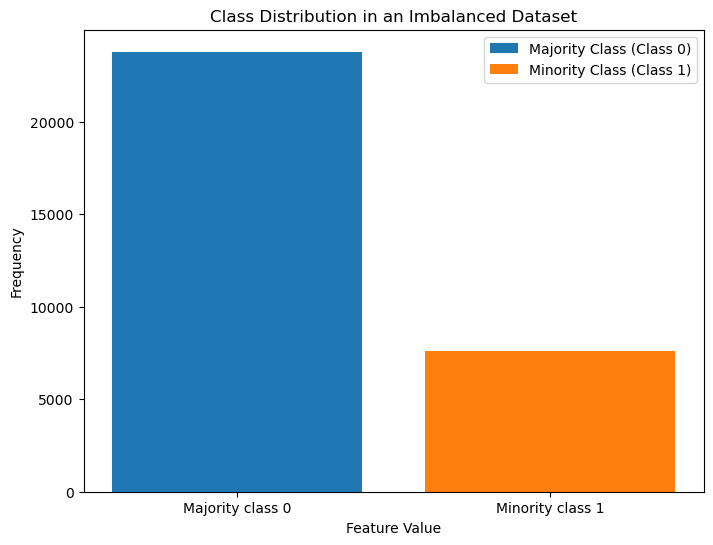

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar("Majority class 0", df4['Incom_enc'].loc[df4["Incom_enc"] == 0].value_counts(), label='Majority Class (Class 0)')
plt.bar("Minority class 1", df4['Incom_enc'].loc[df4["Incom_enc"] == 1].value_counts(), label='Minority Class (Class 1)')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Class Distribution in an Imbalanced Dataset')
plt.legend()
plt.show()

In [54]:
# Importing imblearn, scikit-learn library
from imblearn.over_sampling import SMOTE

# For oversampling of minority class
smote = SMOTE()
X = df4.loc[:, df4.columns != 'Income_enc']
Y = df4['Incom_enc']

X_OverSmote, Y_OverSmote = smote.fit_resample(X, Y)
df_over = X_OverSmote
df_over['Incom_enc'] = Y_OverSmote

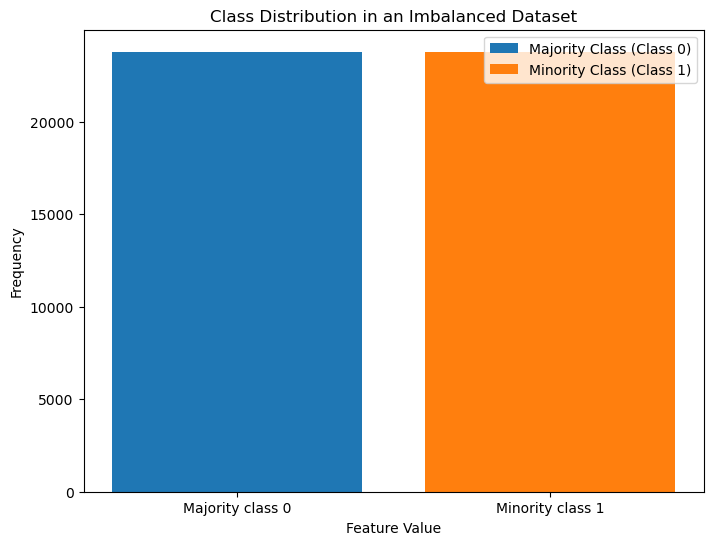

In [55]:
plt.figure(figsize=(8, 6))
plt.bar("Majority class 0", df_over['Incom_enc'].loc[df_over["Incom_enc"] == 0].value_counts(), label='Majority Class (Class 0)')
plt.bar("Minority class 1", df_over['Incom_enc'].loc[df_over["Incom_enc"] == 1].value_counts(), label='Minority Class (Class 1)')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Class Distribution in an Imbalanced Dataset')
plt.legend()
plt.show()

In [56]:

print("Training data distribution (after SMOTE):")
print(pd.Series(Y_OverSmote).value_counts())

Training data distribution (after SMOTE):
Incom_enc
0.0    23794
1.0    23794
Name: count, dtype: int64


# Dataset split

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_OverSmote, Y_OverSmote, test_size = 0.3, random_state=42)

# Applay Decision Tree Classifier:

# 1-criterion gini index

In [61]:
# instantiate the DecisionTreeClassifier model with criterion gini index

model_gini = DecisionTreeClassifier(criterion='gini',)


# fit the model
model_gini.fit(X_train, y_train)


DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[0] <= 0.5\ngini = 0.5\nsamples = 33311\nvalue = [16623, 16688]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 16623\nvalue = [16623, 0]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 16688\nvalue = [0, 16688]')]

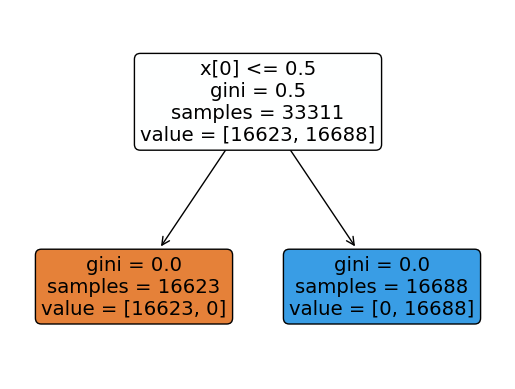

In [62]:
from sklearn.tree import plot_tree
plot_tree(model_gini,filled=True,rounded=True)

In [63]:
y_pred_gini = model_gini.predict(X_test)
y_pred_train_gini = model_gini.predict(X_train)

# Check for overfitting and underfitting
<p>We can see that the training-set score and test-set score is same as above. The training-set accuracy score is 1 while the test-set accuracy to be 1 These two values are quite comparable. So, there is no sign of overfitting.</p> 


In [65]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(model_gini.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(model_gini.score(X_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


# 2-criterion entropy

In [67]:
# instantiate the DecisionTreeClassifier model with criterion entropy

model_entropy = DecisionTreeClassifier(criterion='entropy')


# fit the model
model_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [68]:
y_pred_en = model_entropy.predict(X_test)

# Check accuracy score with criterion entropy
<p>We can see that the training-set score and test-set score is same as above. The training-set accuracy score is 1 while the test-set accuracy to be 1 These two values are quite comparable. So, there is no sign of overfitting.</p> 


In [70]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(model_entropy.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(model_entropy.score(X_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


<h3>3- Finding the optimal parameters of the decision tree </h3>

<h3> Pre-pruning technique </h3>

In [72]:
from sklearn.model_selection import GridSearchCV

tree_params = [{'max_depth': list(range(1, 15)), 'criterion': ['entropy', 'gini'] }]

clf = DecisionTreeClassifier()

model = GridSearchCV(clf, tree_params, cv = 10, scoring='accuracy')

model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid=[{'criterion': ['entropy', 'gini'],
                          'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                        13, 14]}],
             scoring='accuracy')

In [73]:
model.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=1)

#  Draw Tree

[Text(0.5, 0.75, 'x[0] <= 0.5\nentropy = 1.0\nsamples = 33311\nvalue = [16623, 16688]'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 16623\nvalue = [16623, 0]'),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 16688\nvalue = [0, 16688]')]

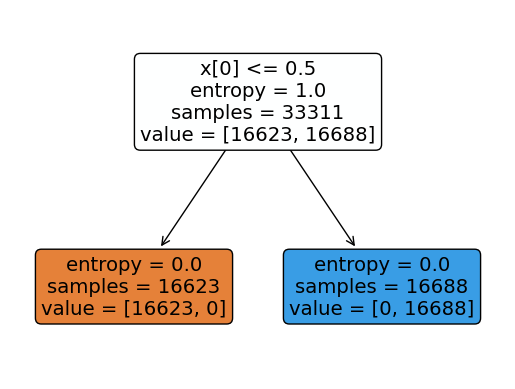

In [75]:
# Implementing the values 
model_optimal = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)


# fit the model
model_optimal.fit(X_train, y_train)

plot_tree(model_optimal,filled=True,rounded=True)

In [76]:
y_pred_en_op = model_optimal.predict(X_test)

# Evaluate the model_optimal

In [78]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(model_optimal.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(model_optimal.score(X_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


In [79]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_en_op)

print('Confusion matrix\n\n', cm)



Confusion matrix

 [[7171    0]
 [   0 7106]]


In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_en_op))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7171
         1.0       1.00      1.00      1.00      7106

    accuracy                           1.00     14277
   macro avg       1.00      1.00      1.00     14277
weighted avg       1.00      1.00      1.00     14277



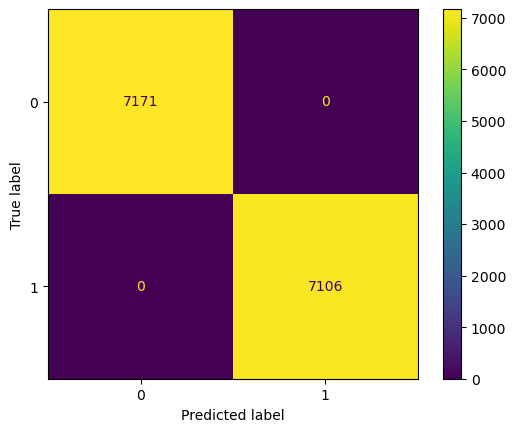

In [81]:
from sklearn import metrics
import matplotlib.pyplot as plt

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_en_op), display_labels = [0, 1])

cm_display.plot()
plt.show()

In [82]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_en_op})

In [83]:
print(comparison_df.head(50))

       Actual  Predicted
23757     0.0        0.0
43650     1.0        1.0
12969     1.0        1.0
46590     1.0        1.0
27863     1.0        1.0
6756      0.0        0.0
14320     0.0        0.0
1219      0.0        0.0
14712     1.0        1.0
43524     1.0        1.0
8256      0.0        0.0
12981     0.0        0.0
35412     1.0        1.0
9068      0.0        0.0
22630     0.0        0.0
12004     1.0        1.0
16451     0.0        0.0
15127     0.0        0.0
16823     0.0        0.0
36477     1.0        1.0
12532     0.0        0.0
45443     1.0        1.0
5080      0.0        0.0
8466      1.0        1.0
26932     0.0        0.0
37590     1.0        1.0
884       0.0        0.0
34544     1.0        1.0
5199      1.0        1.0
43191     1.0        1.0
24872     0.0        0.0
27625     0.0        0.0
17851     0.0        0.0
16752     0.0        0.0
34405     1.0        1.0
10915     0.0        0.0
14896     0.0        0.0
31945     1.0        1.0
21600     0.0        0.0
